 *** file saved ... figures/hopfield_sorted_states_2mem.txt


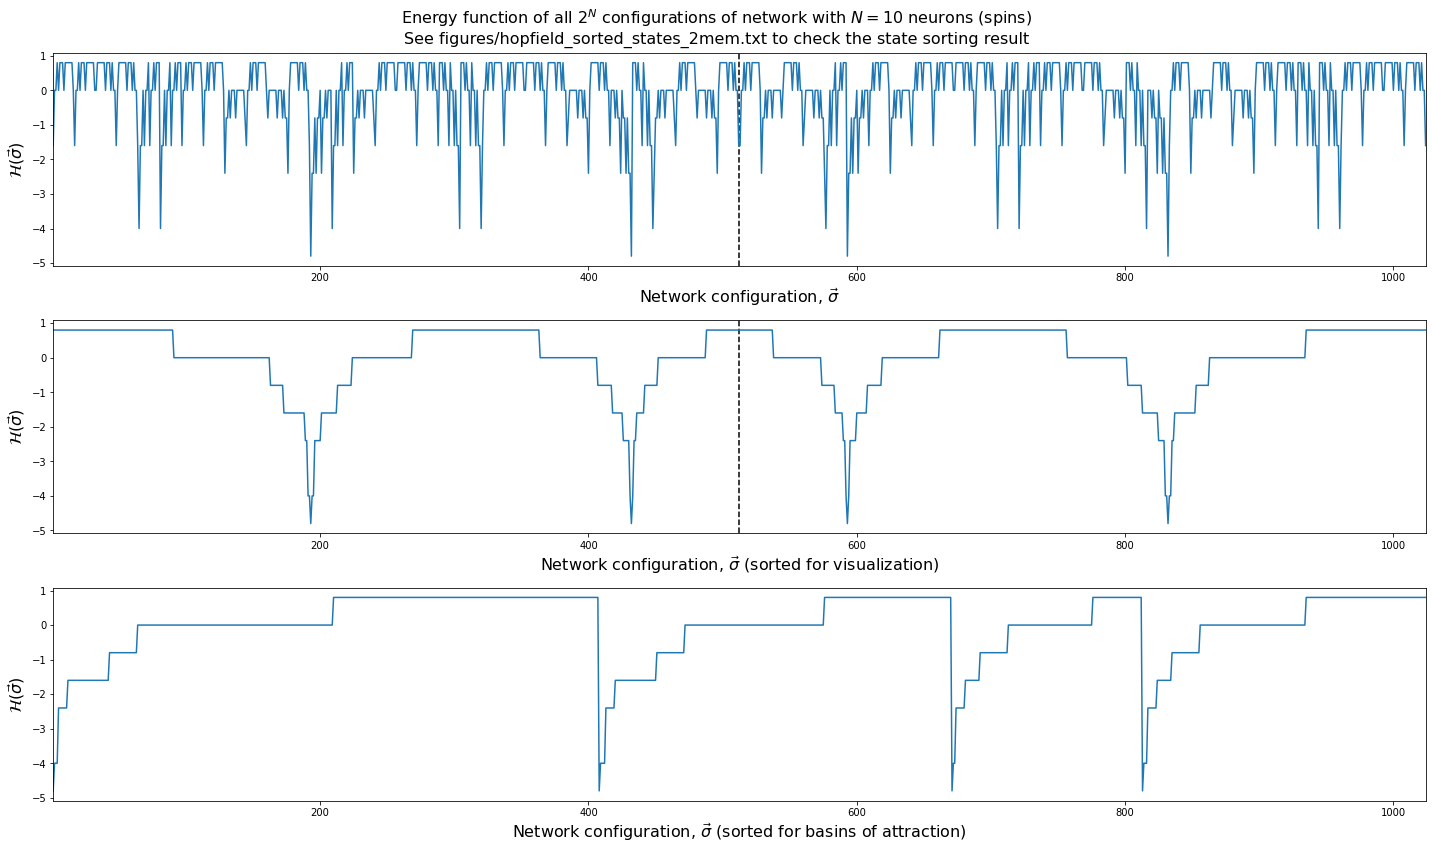

In [1]:
import modules.hopfield as hopfield
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(53)


state_to_str    = lambda state: ''.join([ ('+' if s>0 else '-') for s in state ])


N               = 10
P               = 2 # number of patterns
patterns        = [ 2*np.random.randint(2,size=N)-1 for mu in range(P) ]
add_anti_states = lambda S: np.vstack((S,-np.flipud(S)))

W,N,patterns  = hopfield.initialize_hopfield_model(patterns)
states_set    = add_anti_states(hopfield.generate_ising_states(N))
E             = np.array([hopfield.calculate_energy(W, s) for s in states_set])

# memories and antimemories
all_memories  = np.concatenate((np.array(patterns),-np.array(patterns)))
state_mem     = [None for _ in states_set]
for n,s0 in enumerate(states_set):
    s1 = hopfield.iterate_hopfield_sequential(W,s0)[0]
    m  = hopfield.find_first([np.array_equal(s1, xi) for xi in all_memories])
    state_mem[n] = m
state_mem             = np.array(state_mem)
states_basin, E_basin = hopfield.sort_basins(state_mem,E)

states_sorted,sorted_ind,E_sorted = hopfield.sort_states_around_energy_minima(states_set, E, patterns)

hopfield.save_sorted_state_txt('figures/hopfield_sorted_states_2mem.txt',states_set, patterns, sorted_ind, states_sorted, states_basin, state_mem[states_basin])


fig,ax = plt.subplots(3,1,sharey=True,figsize=(20,12))

ax[0].axvline(2**(N-1),ls='--',c='k')
ax[1].axvline(2**(N-1),ls='--',c='k')
ax[0].plot(np.arange(1,E.size+1),E)
ax[1].plot(np.arange(1,E.size+1),E_sorted)
ax[2].plot(np.arange(1,E.size+1),E_basin)

ax[0].set_xlabel(r'Network configuration, $\vec{\sigma}$',fontsize=16)
ax[0].set_ylabel(r'$\mathcal{H}(\vec{\sigma})$',fontsize=16)
ax[1].set_xlabel(r'Network configuration, $\vec{\sigma}$ (sorted for visualization)',fontsize=16)
ax[1].set_ylabel(r'$\mathcal{H}(\vec{\sigma})$',fontsize=16)
ax[2].set_xlabel(r'Network configuration, $\vec{\sigma}$ (sorted for basins of attraction)',fontsize=16)
ax[2].set_ylabel(r'$\mathcal{H}(\vec{\sigma})$',fontsize=16)
ax[0].autoscale(enable=True, axis='x', tight=True)
ax[1].autoscale(enable=True, axis='x', tight=True)
ax[2].autoscale(enable=True, axis='x', tight=True)


fig.suptitle('Energy function of all $2^N$ configurations of network with $N=10$ neurons (spins)\nSee figures/hopfield_sorted_states_2mem.txt to check the state sorting result',fontsize=16)
fig.tight_layout()

fig.savefig('figures/hopfield_sorted_states_2mem.png', format='png', bbox_inches='tight')

plt.show()

Create the weights matrix for an $N=10$ network
and store (a) 1; (b) 2; and (c) 3 memories in it using the Hebb rule.
Compute and plot the Hamiltonian
using $H_i=0$ for all the $2^{N}=1024$ possible patterns.
Sort the patterns on the horizontal axis such that the energy minima are visible.
Label each of the $2^N$ configurations with an unique index (e.g., $n=1,\cdots,2^N$).
Use each configuration as an initial condition and iterate the Hopfield dynamics.
Now, plot the Hamiltonian with symbols versus the state labels,
and color each state symbol according to which of the memories it converged to
(e.g., red if it converged to the first memory, blue for the second, etc).

In [2]:
patterns

[array([ 1,  1,  1,  1,  1,  1, -1, -1,  1,  1]),
 array([-1, -1, -1, -1,  1, -1,  1, -1, -1,  1])]

array([192, 431, 592, 831])

In [32]:
np.nonzero(E==np.min(E))[0]

array([192, 431, 592, 831], dtype=int64)

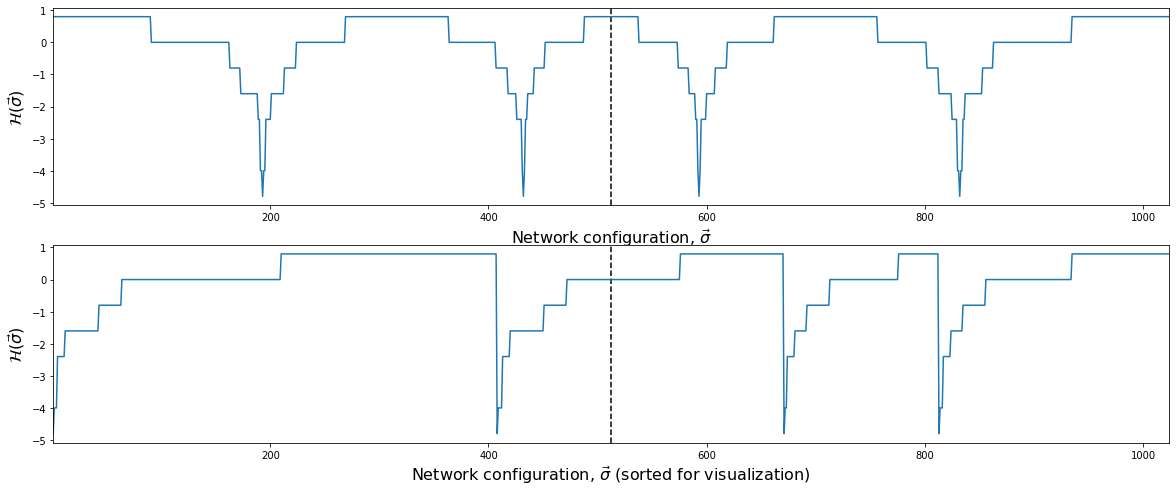

In [ ]:
import modules.hopfield as hopfield
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(53)

N               = 10
P               = 2 # number of patterns
patterns        = [ 2*np.random.randint(2,size=N)-1 for mu in range(P) ]
add_anti_states = lambda S: np.vstack((S,-np.flipud(S)))

W,N,patterns  = hopfield.initialize_hopfield_model(patterns)
states_set    = add_anti_states(hopfield.generate_ising_states(N))
E             = np.array([hopfield.calculate_energy(W, s) for s in states_set])




fig,ax = plt.subplots(2,1,sharey=True,figsize=(20,8))

ax[0].axvline(2**(N-1),ls='--',c='k')
ax[1].axvline(2**(N-1),ls='--',c='k')
ax[0].plot(np.arange(1,E_sorted.size+1),E_sorted)
ax[1].plot(np.arange(1,E_sorted.size+1),E_basin)


ax[0].set_xlabel(r'Network configuration, $\vec{\sigma}$',fontsize=16)
ax[0].set_ylabel(r'$\mathcal{H}(\vec{\sigma})$',fontsize=16)
ax[1].set_xlabel(r'Network configuration, $\vec{\sigma}$ (sorted for visualization)',fontsize=16)
ax[1].set_ylabel(r'$\mathcal{H}(\vec{\sigma})$',fontsize=16)
ax[0].autoscale(enable=True, axis='x', tight=True)
ax[1].autoscale(enable=True, axis='x', tight=True)